# 2.5 Tensor

Finally, we define tensors which are the central object of CuTe by binding a layout to an accessor. The accessor is effectively a random-access, pointer-like object for the layout.

**Definition 2.18.** An accessor is an object that supports offset and dereference operations:

- $e + d \to e'$, offset accessor $e$ by $d \in D$ to produce another accessor $e'$;
- $*e \to v$, dereference accessor $e$ to produce value $v$;
- $e[d] \to *(e + d)$, subscript operator as a common convenience.

When $D = \mathbb{Z}$, common implementations of an accessor include raw pointers (e.g., `T*`), arrays (e.g. `T[N]`), and random-access iterators (e.g. `thrust::counting_iterator` and `thrust::transform_iterator`, etc).

**Definition 2.19.** A tensor is defined by the composition of an accessor, $e$, with a layout, $L$, expressed as $T = e \circ L$. A tensor evaluates the layout by mapping a coordinate $c \in \mathbb{Z}(L)$ to the codomain $D$, offsets the accessor accordingly, and dereferences the result to obtain the tensor's value. Formally,

$$T(c) = (e \circ L)(c) = *(e + L(c)) = e[L(c)],$$

yields the value of the tensor at coordinate $c$.

In [1]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_slice

Most tensors are data layouts that use a memory address as an accessor. For instance, a memory address $p$ can be used as a pointer accessor $\{p\}$ with normal offset and dereference operations to construct a data tensor,

$$\{p\} + b \to \{p + b\}, \quad *\{p\} \to *p, \quad T = \{p\} \circ L.$$

In addition, all layouts can be transformed into implicit tensors by composing them with a counting iterator $\{a\}$ which dereferences to a stored offset $a \in \mathbb{Z}$,

$$\{a\} + b \to \{a + b\}, \quad *\{a\} \to a, \quad T = \{a\} \circ L.$$

In `tensor_layouts`, a `Tensor` wraps a `Layout` with an integer offset (acting as a counting iterator).

In [2]:
# A data tensor: 4x8 column-major matrix at base offset 0
L = Layout((4, 8), (1, 4))
T = Tensor(L, offset=0)
print(f"Tensor: {T}")
print(f"  Layout: {T.layout}")
print(f"  Offset: {T.offset}")
print()

# T(c) = *(e + L(c)) = e[L(c)]
# With a counting iterator, T(c) = offset + L(c)
print("Evaluating T(c) = offset + L(c):")
for j in range(3):
    for i in range(4):
        val = T(i, j)
        assert val == T.offset + L(i, j)  
        print(f"  T({i},{j}) = {T.offset} + L({i},{j}) = {T.offset} + {L(i,j)} = {val}")
    print()

Tensor: {0} ∘ (4, 8) : (1, 4)
  Layout: (4, 8) : (1, 4)
  Offset: 0

Evaluating T(c) = offset + L(c):
  T(0,0) = 0 + L(0,0) = 0 + 0 = 0
  T(1,0) = 0 + L(1,0) = 0 + 1 = 1
  T(2,0) = 0 + L(2,0) = 0 + 2 = 2
  T(3,0) = 0 + L(3,0) = 0 + 3 = 3

  T(0,1) = 0 + L(0,1) = 0 + 4 = 4
  T(1,1) = 0 + L(1,1) = 0 + 5 = 5
  T(2,1) = 0 + L(2,1) = 0 + 6 = 6
  T(3,1) = 0 + L(3,1) = 0 + 7 = 7

  T(0,2) = 0 + L(0,2) = 0 + 8 = 8
  T(1,2) = 0 + L(1,2) = 0 + 9 = 9
  T(2,2) = 0 + L(2,2) = 0 + 10 = 10
  T(3,2) = 0 + L(3,2) = 0 + 11 = 11



In [3]:
# A tensor with a nonzero offset acts like a pointer offset from base
T_offset = Tensor(L, offset=100)
print(f"Tensor with offset=100: {T_offset}")
print(f"  T(0,0) = {T_offset(0,0)}")
print(f"  T(2,3) = {T_offset(2,3)}")
print(f"  = 100 + L(2,3) = 100 + {L(2,3)} = {100 + L(2,3)}")

Tensor with offset=100: {100} ∘ (4, 8) : (1, 4)
  T(0,0) = 100
  T(2,3) = 114
  = 100 + L(2,3) = 100 + 14 = 114


Layout of the 4x8 column-major tensor:


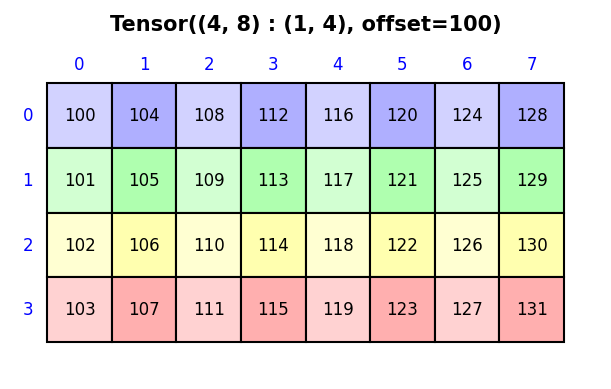

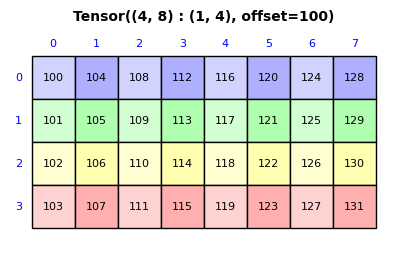

In [4]:
# Visualize the layout of our tensor
print("Layout of the 4x8 column-major tensor:")
draw_layout(T_offset, colorize=True)

## 2.5.1 Slicing

A tensor may be either fully evaluated or partially evaluated through slicing. As a CuTe Tensor can be thought of as a Layout with an offset, arbitrary slicing can be performed along any mode(s) of a natural coordinate.

- **Full evaluation:** Applying Eq. (9) with a complete coordinate $c$ results in a value.
- **Partial evaluation (Slicing):** When slicing with an incomplete coordinate $c = c' + c^*$, where $c^*$ represents the unspecified portion of $c$, the result is a new tensor. The operation is expressed as:

$$T(c) = (e \circ L)(c' + c^*) = (e + L(c')) \circ L(c^*) = e' \circ L(c^*) = T'(c^*),$$

where $L(c')$ can be fully evaluated and accumulated into $e$ and $L(c^*)$ is the sublayout of $L$ that remains unevaluated. Slicing creates a sub-tensor that can be further evaluated or manipulated.

In [5]:
# Simple slicing on a 4x8 column-major layout
L = Layout((4, 8), (1, 4))

# Fix column j=3: extracts row vector (the 3rd column)
# L(None, 3) gives the sublayout, L(0, 3) gives the offset
sub_col3 = L(None, 3)
off_col3 = L(0, 3)
print(f"L = {L}")
print(f"Slice L(None, 3):  sublayout = {sub_col3},  offset = {off_col3}")
print(f"  -> Tensor {{offset={off_col3}}} o {sub_col3}")
print()

# Verify: sliced tensor values match original
for i in range(4):
    original = L(i, 3)
    sliced = off_col3 + sub_col3(i)
    assert original == sliced
    print(f"  L({i}, 3) = {original}  ==  {off_col3} + sub({i}) = {sliced}")

L = (4, 8) : (1, 4)
Slice L(None, 3):  sublayout = (4,) : (1,),  offset = 12
  -> Tensor {offset=12} o (4,) : (1,)

  L(0, 3) = 12  ==  12 + sub(0) = 12
  L(1, 3) = 13  ==  12 + sub(1) = 13
  L(2, 3) = 14  ==  12 + sub(2) = 14
  L(3, 3) = 15  ==  12 + sub(3) = 15


In [6]:
# Fix row i=2: extracts column vector (the 2nd row)
sub_row2 = L(2, None)
off_row2 = L(2, 0)
print(f"Slice L(2, None):  sublayout = {sub_row2},  offset = {off_row2}")
print(f"  -> Tensor {{offset={off_row2}}} o {sub_row2}")
print()

for j in range(8):
    original = L(2, j)
    sliced = off_row2 + sub_row2(j)
    assert original == sliced
    print(f"  L(2, {j}) = {original:2d}  ==  {off_row2} + sub({j}) = {sliced}")

Slice L(2, None):  sublayout = (8,) : (4,),  offset = 2
  -> Tensor {offset=2} o (8,) : (4,)

  L(2, 0) =  2  ==  2 + sub(0) = 2
  L(2, 1) =  6  ==  2 + sub(1) = 6
  L(2, 2) = 10  ==  2 + sub(2) = 10
  L(2, 3) = 14  ==  2 + sub(3) = 14
  L(2, 4) = 18  ==  2 + sub(4) = 18
  L(2, 5) = 22  ==  2 + sub(5) = 22
  L(2, 6) = 26  ==  2 + sub(6) = 26
  L(2, 7) = 30  ==  2 + sub(7) = 30


Figure 5 illustrates examples of slicing into a $6 \times 12$ matrix to extract rows, columns, and submatrices. These use a counting-iterator accessor denoted by $\{a\}$ to indicate an offset of $a \in \mathbb{Z}$. Slicing involves accumulating into the tensor offset and determining the unevaluated portion of the layout.

A = ((3, 2), ((2, 3), 2)) : ((4, 1), ((2, 15), 100))
Shape: ((3, 2), ((2, 3), 2)), size = 72
  Mode 0 size: 6 (rows)
  Mode 1 size: 12 (cols)



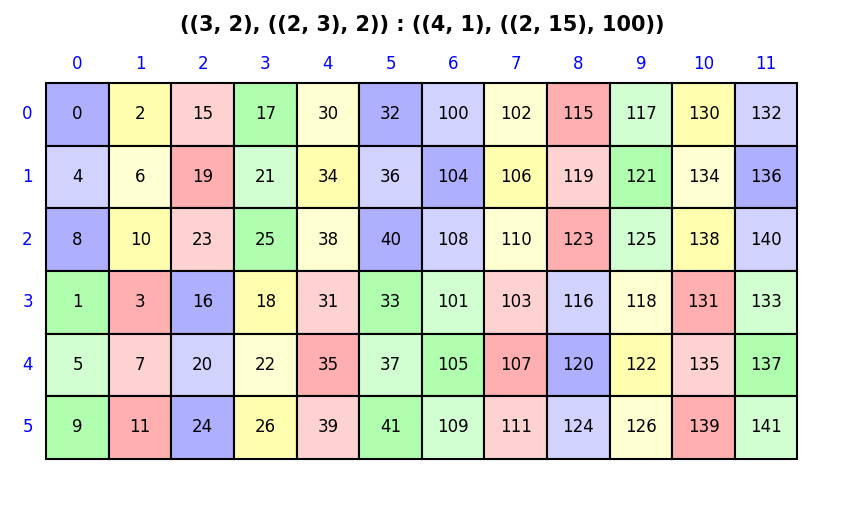

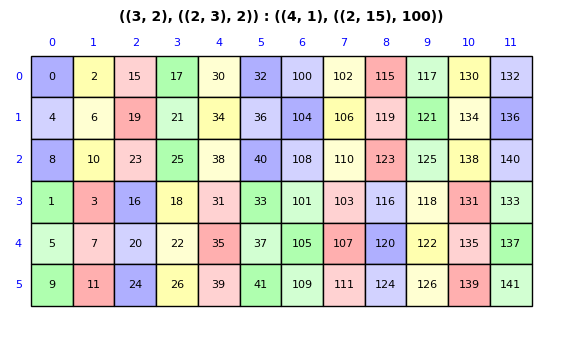

In [7]:
# Figure 5: Tensor A = {0} o ((3,2), ((2,3),2)) : ((4,1), ((2,15),100))
# This is a 6x12 matrix with hierarchical shape
A = Layout(((3, 2), ((2, 3), 2)), ((4, 1), ((2, 15), 100)))
print(f"A = {A}")
print(f"Shape: {A.shape}, size = {size(A)}")
print(f"  Mode 0 size: {size(mode(A, 0))} (rows)")
print(f"  Mode 1 size: {size(mode(A, 1))} (cols)")
print()
draw_layout(A, colorize=True)

A(2, _):
  offset = 8
  sublayout = ((2, 3), 2) : ((2, 15), 100)
  -> Tensor {8} ∘ ((2, 3), 2) : ((2, 15), 100)

  Verified: all 12 column values match.


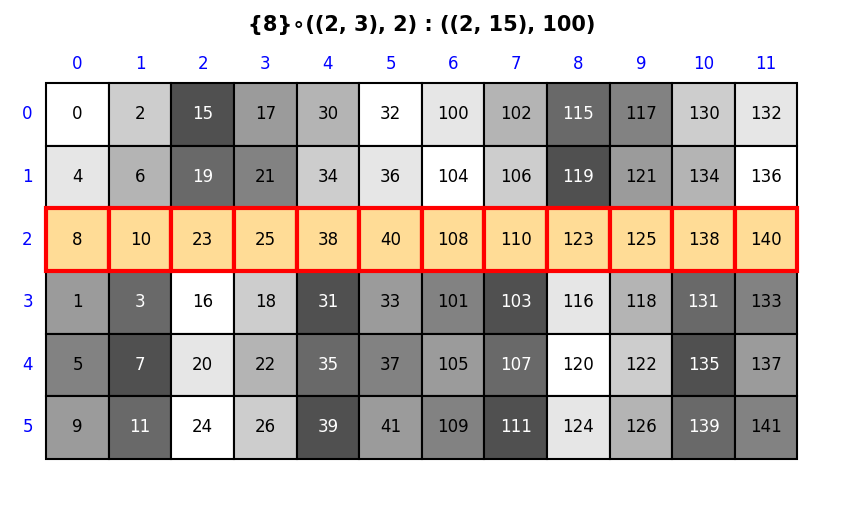

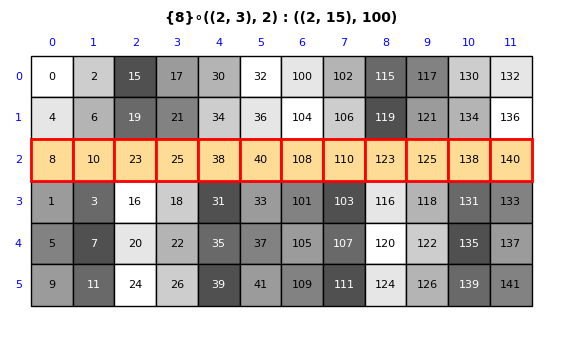

In [8]:
# Slice 1: A(2, _) -> {8} o ((2,3),2) : ((2,15),100)
# Fix row coordinate to 2, keep all column coordinates
T = Tensor(A)
slice=(2,None)
Ts = T[slice]
print(f"A(2, _):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

# Verify all elements match
for j in range(size(mode(A, 1))):
    assert A(2, j) == Ts.offset + Ts.layout(j)
print(f"  Verified: all {size(mode(A, 1))} column values match.")
draw_slice(T, slice)

A(_, 5):
  offset = 32
  sublayout = (3, 2) : (4, 1)
  -> Tensor {32} ∘ (3, 2) : (4, 1)

  Verified: all 6 row values match.


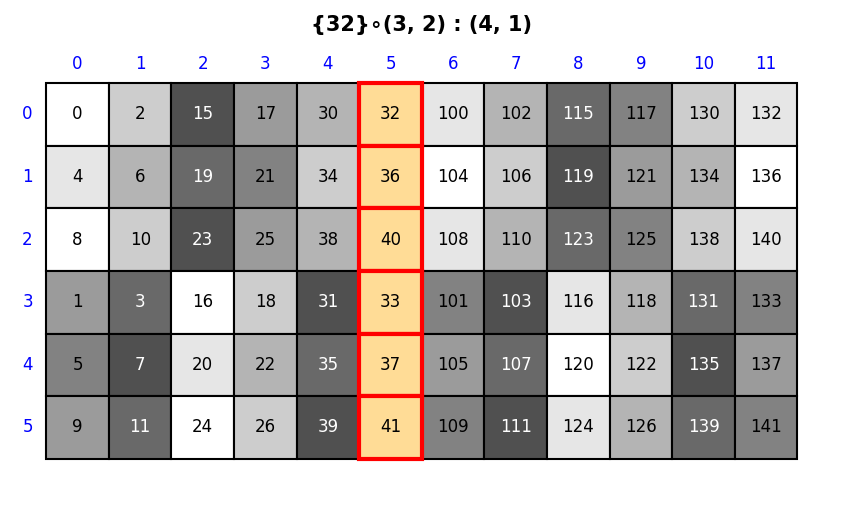

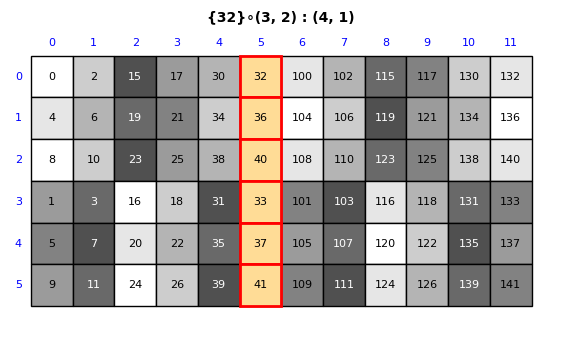

In [9]:
# Slice 2: A(_, 5) -> {32} o (3,2) : (4,1)
# Fix column coordinate to 5, keep all row coordinates
slice = (None, 5)
Ts = T[slice]
print(f"A(_, 5):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

for i in range(size(mode(A, 0))):
    assert A(i, 5) == Ts.offset + Ts.layout(i)
print(f"  Verified: all {size(mode(A, 0))} row values match.")
draw_slice(T, slice)

Ts={8} ∘ (3, 2) : (15, 100)
A(2, ((0, _, _)):
  offset = 8
  sublayout = (3, 2) : (15, 100)
  -> Tensor {8} ∘ (3, 2) : (15, 100)

  Verified: all 6 values match.


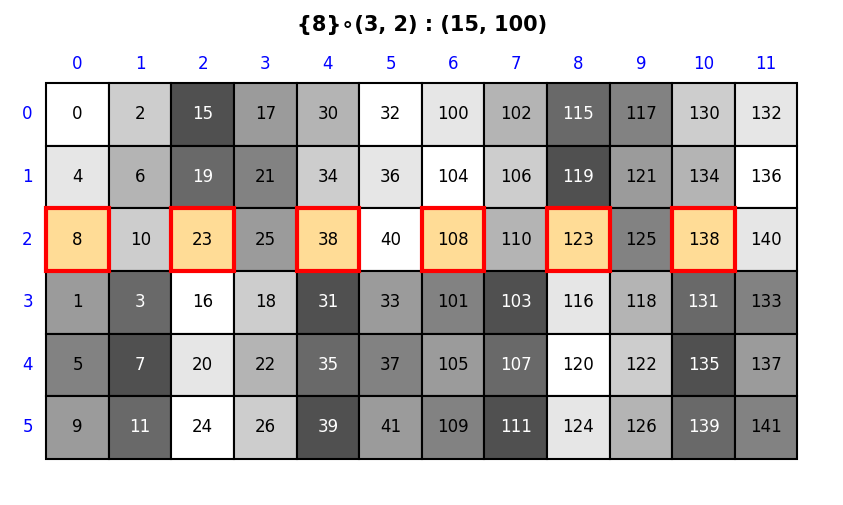

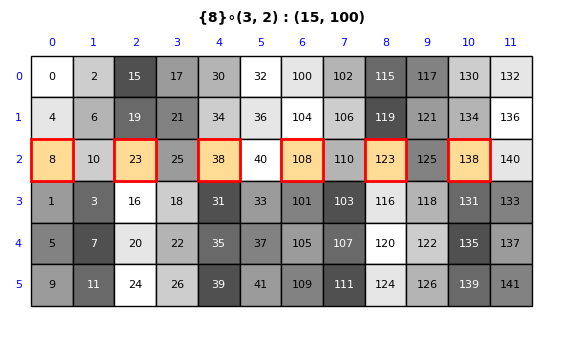

In [10]:
# Slice 3: A(2, ((0, _), _)) -> {8} o (3, 2) : (15, 100)
# Fix row to 2, and fix the first sub-coordinate of mode 1 to 0
slice = (2, ((0, None), None))
Ts = T[slice]
print(f"Ts={Ts}")
print(f"A(2, ((0, _, _)):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

# This extracts a 3x2 submatrix
for j1 in range(3):
    for j2 in range(2):
        assert A(2, ((0, j1), j2)) == Ts.offset + Ts.layout(j1, j2)
print(f"  Verified: all {size(Ts.layout)} values match.")
draw_slice(T, slice)

A((_, 1), (_, 0)):
  offset = 1
  sublayout = (3, (2, 3)) : (4, (2, 15))
  -> Tensor {1} ∘ (3, (2, 3)) : (4, (2, 15))

  Verified: all 18 values match.


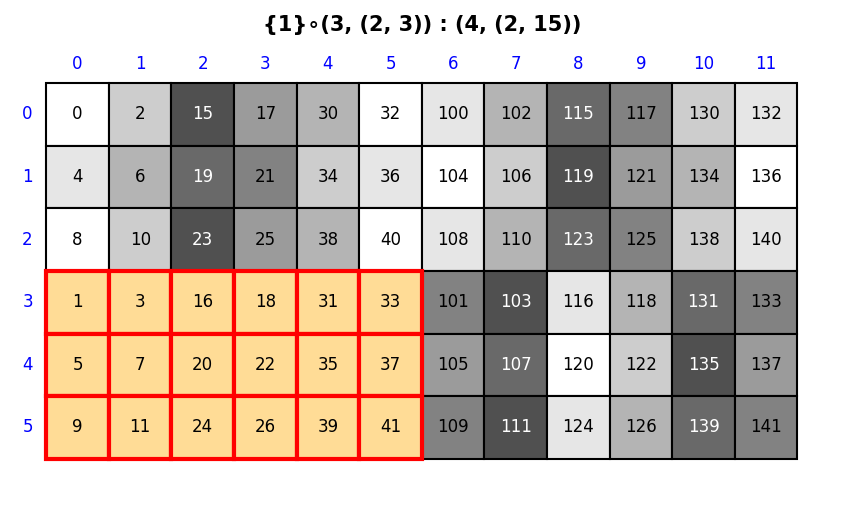

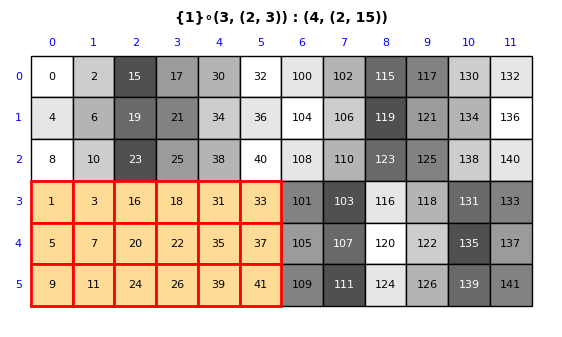

In [11]:
# Slice 4: A((_, 1), (_, 0)) -> {1} o (3, (2, 3)) : (4, (2, 15))
# Fix second sub-coord of mode 0 to 1, first sub-coord of mode 1 to 0
slice = ((None, 1), (None, 0))
Ts = T[slice]
print(f"A((_, 1), (_, 0)):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

for i in range(3):
    for j in range(size(mode(Ts.layout, 1))):
        assert A((i, 1), (j, 0)) == Ts.offset + Ts.layout(i, j)
print(f"  Verified: all {size(Ts.layout)} values match.")
draw_slice(T, slice)

A((_, 0), ((0, _), 1)):
  offset = 100
  sublayout = (3, 3) : (4, 15)
  -> Tensor {100} ∘ (3, 3) : (4, 15)

  Verified: all 9 values match.


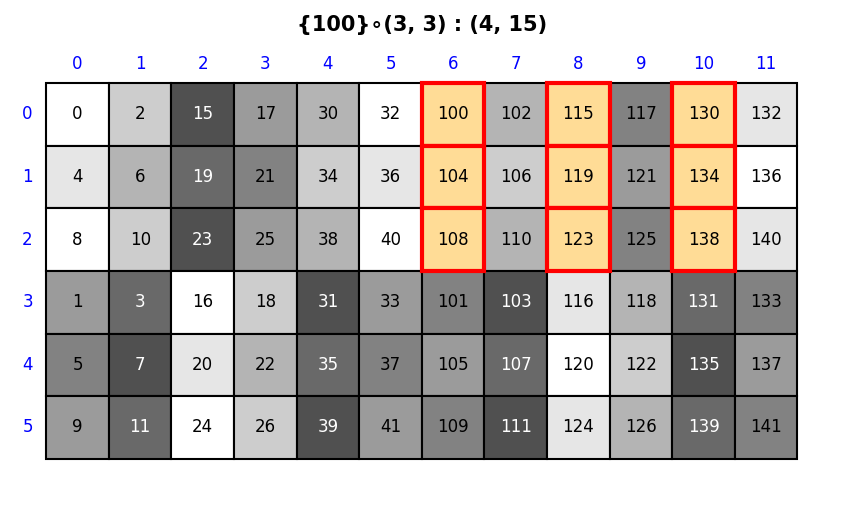

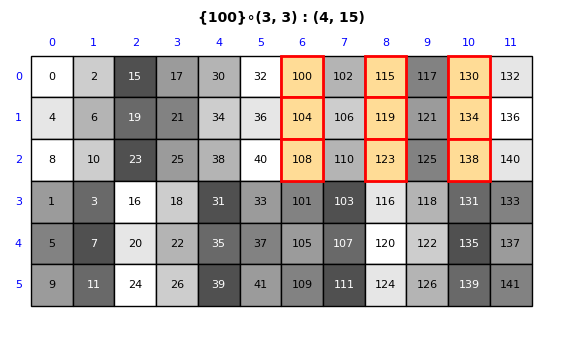

In [12]:
# Slice 5: A((_, 0), ((0, _), 1)) -> {100} o (3, 3) : (4, 15)
# Fix second sub-coord of mode 0 to 0, first sub-coord of mode 1's
# first sub-mode to 0, and mode 1's second sub-coord to 1
slice = ((None, 0), ((0, None), 1))
Ts = T[slice]
print(f"A((_, 0), ((0, _), 1)):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

for i in range(3):
    for j in range(3):
        assert A((i, 0), ((0, j), 1)) == Ts.offset + Ts.layout(i, j)
print(f"  Verified: all {size(Ts.layout)} values match.")
draw_slice(T, slice)

A((1, _), ((_, 0), _)):
  offset = 4
  sublayout = (2, (2, 2)) : (1, (2, 100))
  -> Tensor {4} ∘ (2, (2, 2)) : (1, (2, 100))

  Verified: all 8 values match.


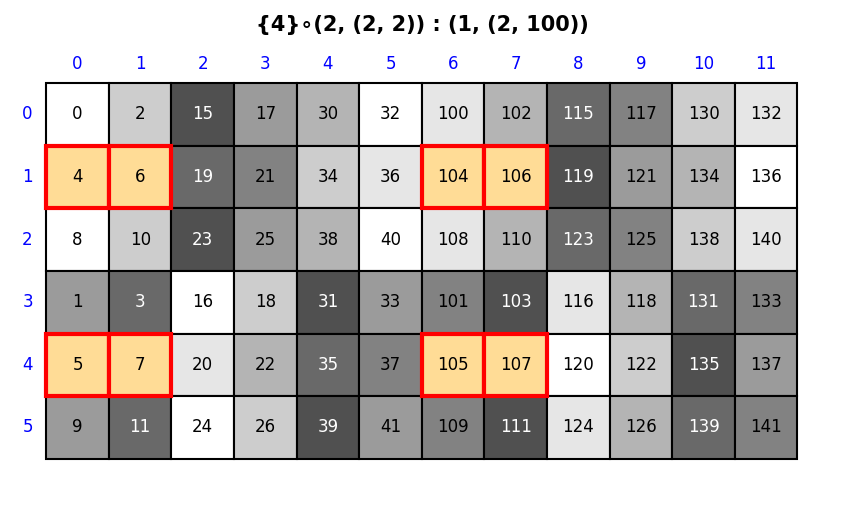

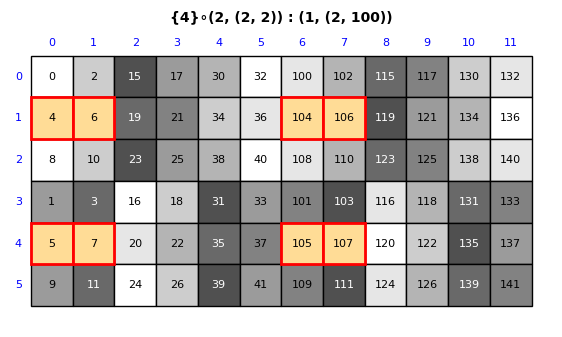

In [13]:
# Slice 6: A((1, _), ((_, 0), _)) -> {4} o (2, (2, 2)) : (1, (2, 100))
# Fix first sub-coord of mode 0 to 1, second sub-coord of mode 1's
# first sub-mode to 0
slice = ((1, None), ((None, 0), None))
Ts = T[slice]
print(f"A((1, _), ((_, 0), _)):")
print(f"  offset = {Ts.offset}")
print(f"  sublayout = {Ts.layout}")
print(f"  -> Tensor {Ts}")
print()

# Verify: sub is rank-3 since the library flattens (2, (2, 2)) -> (2, 2, 2)
for i1 in range(2):
    for j0 in range(2):
        for j2 in range(2):
            assert A((1, i1), ((j0, 0), j2)) == Ts.offset + Ts.layout(i1, (j0, j2))
print(f"  Verified: all {size(Ts.layout)} values match.")
draw_slice(T, slice)

The key insight is that CuTe's hierarchical shapes allow slicing at *any sub-boundary* of the layout, not just along entire modes. This is strictly more powerful than the ranged slicing offered by libraries like NumPy or PyTorch.

In many tensor libraries like `numpy.ndarray`, `torch.tensor`, and MATLAB, slicing is supported with notation similar to above: write `my_matrix[2,:]` to extract the second row of a matrix and `my_matrix[:,4]` to extract the fourth column of a matrix. These libraries also support ranged slicing, such as `my_matrix[2:4,1:3]` to extract the submatrix from the second to the fourth row and the first to the third column. CuTe does not support ranged slicing as it finds ranged slicing to be problematic for several reasons:

- Ranged slicing can't express all of the slices demonstrated in Figure 5. The last slice example cannot be expressed with ranged slicing on only the rows and columns of a matrix.
- Ranged slicing promotes patterns like
  ```python
  thr_data = my_data[thr_id*TILE_SIZE:(thr_id+1)*TILE_SIZE]
  ```
  to retrieve a "tile" of data local to each thread. This pattern conflates the `TILE_SIZE`, which is very often a static constant that a program wants to optimize over, with a `thr_id`, which is a fundamentally dynamic index local to each thread. Instead, CuTe prefers a two-stage permute-and-slice approach.
- Ranged slicing can express slices that are impossible to represent with a CuTe layout.